# Trabalho 10 — Realce por manipulação de histogramas
## Função de transferência linear aplicada a PGM e PPM

**Disciplina:** Computação Gráfica / Processamento de Imagens Digitais
**Professor:** André Alessandro Stein
**Aluno:** Igor
**Instituição:** IFC — Campus Rio do Sul

### Enunciado

> **a)** Utilizar a função de transferência do material sobre histograma para
> gerar as imagens e gráfico sobre a imagem (PGM). Gerar o histograma da imagem
> gerada.
>
> **b)** Idem para a imagem PPM (RGB). Gerar o histograma da imagem gerada.

### A função de transferência do material

O material `Histograma_Linear.pdf` define o realce linear de contraste pelo
procedimento:

1. Percorrer a imagem `X` para descobrir `Xmin` e `Xmax`.
2. Calcular `a = 255,0 / (Xmax − Xmin)`.
3. Calcular `b = −a · Xmin`.
4. Aplicar `Y = a·X + b` a cada nível digital.

O objetivo, nas palavras do material, é obter uma imagem "cujo histograma está
completamente espalhado no domínio dos valores determinados para a codificação
da imagem".

### Entregáveis

| Item | Imagem realçada | Gráfico da função | Histograma | CSV |
|------|-----------------|-------------------|------------|-----|
| (a) | PGM P2 | sim | antes e depois | sim |
| (b) | PPM P3 | um por canal | antes e depois, por canal | sim |

### Referências

- HECK, C.; STEIN, A. A. *Realce de Imagens Digitais — Histograma Linear*, 2022.
- STEIN, A. A.; HECK, C. *Processamento de Imagens Digitais* — slides da disciplina.
- LOPES, J. M. Brisson. *Formatos de Imagem*. DEI — IST, Lisboa, 2003 (reed. 2013).

## 1. Fundamentação

### De onde vem a fórmula

A transformação é uma reta que leva o intervalo ocupado pela imagem,
`[Xmin, Xmax]`, sobre o intervalo inteiro da codificação, `[0, 255]`. Impondo as
duas condições de extremo:

    a·Xmin + b = 0        (o valor mais escuro vira preto absoluto)
    a·Xmax + b = 255      (o valor mais claro vira branco absoluto)

Subtraindo a primeira da segunda:

    a·(Xmax − Xmin) = 255     ⟹     a = 255 / (Xmax − Xmin)

e substituindo de volta:

    b = −a · Xmin

que é exatamente o procedimento do material. O coeficiente `a` é o **ganho de
contraste**: quanto mais estreita a faixa ocupada pela imagem original, maior o
alongamento.

### O que o realce faz e o que não faz

Esta é a distinção mais importante do trabalho.

O realce linear **espalha** os níveis existentes sobre a escala inteira. Ele
**não cria** níveis novos: a transformação é monotônica e injetora, de modo que
dois níveis distintos na entrada continuam distintos na saída, e dois níveis
iguais continuam iguais.

A consequência direta: a **quantidade de níveis ocupados não aumenta**. O que
muda é a distância entre eles. Se a imagem original ocupava 231 níveis
concentrados numa faixa estreita, a realçada ocupará os mesmos 231 níveis,
agora distribuídos de 0 a 255 — com lacunas entre eles.

O histograma da imagem realçada terá, por isso, aspecto de **pente**: barras
separadas por posições vazias. Isso não é defeito da implementação; é a
assinatura inevitável de um alongamento aplicado a dados discretos.

Em outras palavras, o realce melhora a **aparência** da imagem sem acrescentar
informação. Ele torna visível o que já estava lá, comprimido numa faixa estreita
demais para o olho distinguir.

### Arredondamento e saturação

Como `a` raramente é inteiro, `a·X + b` produz valores fracionários. Duas
providências:

- **Arredondamento** ao inteiro mais próximo, pelo mesmo motivo das atividades
  anteriores: o truncamento erraria sempre para baixo.
- **Saturação** em `[0, 255]`, por segurança. Com `Xmin` e `Xmax` extraídos da
  própria imagem a fórmula já garante o intervalo, mas a saturação passa a ser
  indispensável quando a faixa é escolhida manualmente — caso tratado ao final
  do notebook, e que o próprio material menciona.

In [2]:
# Bibliotecas e configuração

import csv
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
ENTRADA = BASE / "entrada"
SAIDA = BASE / "saida"
SAIDA.mkdir(exist_ok=True)

ARQUIVO_PGM = ENTRADA / "EntradaEscalaCinza.pgm"
ARQUIVO_PPM = ENTRADA / "EntradaRGB.ppm"

LIMITE_COLUNA = 70
MAXVAL = 255
N_NIVEIS = MAXVAL + 1

print(f"PGM existe : {ARQUIVO_PGM.exists()}")
print(f"PPM existe : {ARQUIVO_PPM.exists()}")

PGM existe : True
PPM existe : True


In [3]:
# --- Leitores e escritores PNM (reaproveitados das atividades anteriores) ---

def _fluxo_tokens(arquivo):
    for linha in arquivo:
        util = linha.split("#", 1)[0]
        for token in util.split():
            yield token


def ler_pnm(caminho):
    """Lê PGM (P2) ou PPM (P3). Devolve (matriz, maxval, magic)."""
    with open(caminho, "r", encoding="ascii") as f:
        it = _fluxo_tokens(f)
        magic = next(it)
        if magic not in ("P2", "P3"):
            raise ValueError(f"Magic number não suportado: {magic!r}")

        largura, altura, maxval = (int(next(it)) for _ in range(3))
        canais = 3 if magic == "P3" else 1
        esperados = largura * altura * canais
        dados = np.fromiter(map(int, it), dtype=np.int32, count=esperados)

    if dados.size != esperados:
        raise ValueError(f"Esperados {esperados} valores, lidos {dados.size}")

    forma = (altura, largura, 3) if canais == 3 else (altura, largura)
    return dados.reshape(forma), maxval, magic


def _escrever_pnm(caminho, magic, imagem, maxval, comentario, limite_coluna):
    imagem = np.asarray(imagem)
    if imagem.min() < 0 or imagem.max() > maxval:
        raise ValueError(f"Valores fora do intervalo [0, {maxval}]")

    if magic == "P3":
        altura, largura, _ = imagem.shape
    else:
        altura, largura = imagem.shape

    n = max(1, (limite_coluna + 1) // (len(str(maxval)) + 1))
    if magic == "P3":
        n = max(3, n - (n % 3))

    plano = imagem.reshape(-1).tolist()

    with open(caminho, "w", encoding="ascii", newline="\n") as f:
        f.write(f"{magic}\n")
        if comentario:
            for trecho in textwrap.wrap(comentario, width=limite_coluna - 2):
                f.write(f"# {trecho}\n")
        f.write(f"{largura} {altura}\n{maxval}\n")
        linhas = [" ".join(map(str, plano[i:i + n]))
                  for i in range(0, len(plano), n)]
        f.write("\n".join(linhas) + "\n")

    return caminho


def escrever_pgm_p2(caminho, imagem, maxval, comentario=None):
    return _escrever_pnm(caminho, "P2", imagem, maxval, comentario, LIMITE_COLUNA)


def escrever_ppm_p3(caminho, imagem, maxval, comentario=None):
    return _escrever_pnm(caminho, "P3", imagem, maxval, comentario, LIMITE_COLUNA)


def verificar_limite_colunas(caminho, limite=LIMITE_COLUNA):
    maior = 0
    with open(caminho, "r", encoding="ascii") as f:
        for numero, linha in enumerate(f, start=1):
            c = len(linha.rstrip("\n"))
            if c > limite:
                raise AssertionError(f"Linha {numero}: {c} caracteres")
            maior = max(maior, c)
    return maior


def histograma(canal, n_niveis=N_NIVEIS):
    """Frequência de cada nível, incluindo os de contagem zero."""
    return np.bincount(canal.ravel(), minlength=n_niveis)

## 2. A função de transferência

A implementação segue o procedimento do material passo a passo. A função devolve
também os parâmetros `a` e `b`, porque eles são necessários para traçar o
gráfico da transformação — um dos entregáveis pedidos.

### Validação contra o exemplo do material

O material traz um exemplo numérico com a matriz 3×3:

    12  20  30
     4  14  10
    55   8  13

de onde `Xmin = 4`, `Xmax = 55`, `a = 255/51 = 5,0` e `b = −20,0`. Uso esse
exemplo como **teste da implementação**: se os parâmetros calculados e a matriz
resultante coincidirem com os do material, a função está correta.

Os parâmetros conferem exatamente. Já na matriz de saída, oito das nove
posições coincidem — a exceção é a posição central-direita, onde o material
apresenta 40 enquanto a fórmula `Y = 5·X − 20` aplicada a `X = 10` resulta em 30.
Parece um erro de digitação do slide (40 é o valor da célula imediatamente acima,
correspondente a `X = 12`). A célula seguinte torna a divergência explícita em
vez de escondê-la.

In [4]:
# --- A função de transferência linear ---

def parametros_realce(imagem, maxval=MAXVAL, xmin=None, xmax=None):
    """
    Calcula os parâmetros a e b do realce linear, conforme o material.

        a = maxval / (Xmax - Xmin)
        b = -a * Xmin

    xmin/xmax podem ser fornecidos para restringir a faixa de interesse;
    quando omitidos, são extraídos da própria imagem.
    """
    xmin = int(imagem.min()) if xmin is None else int(xmin)
    xmax = int(imagem.max()) if xmax is None else int(xmax)

    if xmax == xmin:
        raise ValueError("Xmax igual a Xmin: a imagem tem um único nível.")

    a = maxval / (xmax - xmin)
    b = -a * xmin
    return a, b, xmin, xmax


def aplicar_realce(imagem, a, b, maxval=MAXVAL):
    """Aplica Y = a*X + b com arredondamento e saturação em [0, maxval]."""
    return np.clip(np.rint(a * imagem + b), 0, maxval).astype(np.int32)


# --- Teste contra o exemplo numérico do material ---

X = np.array([[12, 20, 30],
              [ 4, 14, 10],
              [55,  8, 13]])

a, b, xmin, xmax = parametros_realce(X)
Y = aplicar_realce(X, a, b)

Y_material = np.array([[ 40,  80, 130],
                       [  0,  50,  40],
                       [255,  20,  45]])

print(f"Xmin = {xmin}, Xmax = {xmax}")
print(f"a = {a}   (material: 5.0)")
print(f"b = {b}   (material: -20.0)")
assert a == 5.0 and b == -20.0
print("Parâmetros conferem com o material.\n")

print("Matriz calculada:        Matriz do material:")
for lc, lm in zip(Y, Y_material):
    marca = "  <-- divergência" if not np.array_equal(lc, lm) else ""
    print(f"  {str(lc.tolist()):<22} {str(lm.tolist()):<22}{marca}")

divergentes = int((Y != Y_material).sum())
print(f"\nPosições divergentes: {divergentes} de {Y.size}")
if divergentes:
    i, j = np.argwhere(Y != Y_material)[0]
    print(f"  X[{i}][{j}] = {X[i, j]}  ->  calculado {Y[i, j]}, "
          f"material {Y_material[i, j]}")
    print(f"  Conferência: {a}*{X[i, j]} + ({b}) = {a * X[i, j] + b}")
    print("  A fórmula do próprio material confirma o valor calculado;")
    print("  trata-se aparentemente de erro de digitação no slide.")

Xmin = 4, Xmax = 55
a = 5.0   (material: 5.0)
b = -20.0   (material: -20.0)
Parâmetros conferem com o material.

Matriz calculada:        Matriz do material:
  [40, 80, 130]          [40, 80, 130]         
  [0, 50, 30]            [0, 50, 40]             <-- divergência
  [255, 20, 45]          [255, 20, 45]         

Posições divergentes: 1 de 9
  X[1][2] = 10  ->  calculado 30, material 40
  Conferência: 5.0*10 + (-20.0) = 30.0
  A fórmula do próprio material confirma o valor calculado;
  trata-se aparentemente de erro de digitação no slide.


---

## Item (a) — Realce sobre a imagem PGM

In [5]:
# --- Item (a): leitura e parâmetros ---

cinza, mv, magic = ler_pnm(ARQUIVO_PGM)
assert magic == "P2" and mv == MAXVAL
altura, largura = cinza.shape

a_g, b_g, xmin_g, xmax_g = parametros_realce(cinza)

print("IMAGEM ORIGINAL")
print("-" * 52)
print(f"Dimensões      : {largura} x {altura}  ({cinza.size:,} píxeis)")
print(f"Xmin / Xmax    : {xmin_g} / {xmax_g}")
print(f"Faixa ocupada  : {xmax_g - xmin_g + 1} de {N_NIVEIS} níveis "
      f"({(xmax_g - xmin_g + 1) / N_NIVEIS * 100:.1f}% da escala)")
print(f"Média          : {cinza.mean():.2f}")
print(f"Desvio padrão  : {cinza.std():.2f}")
print()
print("PARÂMETROS DA FUNÇÃO DE TRANSFERÊNCIA")
print("-" * 52)
print(f"a = {MAXVAL} / ({xmax_g} - {xmin_g}) = {a_g:.6f}")
print(f"b = -{a_g:.6f} * {xmin_g} = {b_g:.6f}")
print(f"\nY = {a_g:.4f} * X + ({b_g:.4f})")
print(f"\nGanho de contraste: {a_g:.4f}x")

IMAGEM ORIGINAL
----------------------------------------------------
Dimensões      : 800 x 800  (640,000 píxeis)
Xmin / Xmax    : 13 / 243
Faixa ocupada  : 231 de 256 níveis (90.2% da escala)
Média          : 115.93
Desvio padrão  : 53.01

PARÂMETROS DA FUNÇÃO DE TRANSFERÊNCIA
----------------------------------------------------
a = 255 / (243 - 13) = 1.108696
b = -1.108696 * 13 = -14.413043

Y = 1.1087 * X + (-14.4130)

Ganho de contraste: 1.1087x


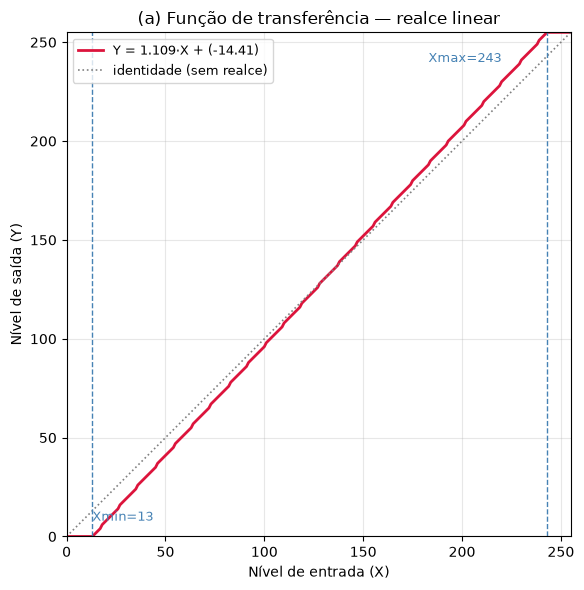

A reta do realce é mais inclinada que a identidade — é isso que
significa ganho de contraste. Ela cruza o eixo horizontal em Xmin e
atinge 255 em Xmax, mapeando a faixa ocupada sobre a escala inteira.


In [6]:
# --- Item (a): gráfico da função de transferência ---

x_eixo = np.arange(N_NIVEIS)
y_eixo = np.clip(np.rint(a_g * x_eixo + b_g), 0, MAXVAL)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_eixo, y_eixo, color="crimson", linewidth=2,
        label=f"Y = {a_g:.3f}·X + ({b_g:.2f})")
ax.plot(x_eixo, x_eixo, color="gray", linestyle=":", linewidth=1.2,
        label="identidade (sem realce)")

ax.axvline(xmin_g, color="steelblue", linestyle="--", linewidth=1)
ax.axvline(xmax_g, color="steelblue", linestyle="--", linewidth=1)
ax.annotate(f"Xmin={xmin_g}", (xmin_g, 8), fontsize=9, color="steelblue")
ax.annotate(f"Xmax={xmax_g}", (xmax_g - 60, 240), fontsize=9, color="steelblue")

ax.set_title("(a) Função de transferência — realce linear")
ax.set_xlabel("Nível de entrada (X)")
ax.set_ylabel("Nível de saída (Y)")
ax.set_xlim(0, MAXVAL)
ax.set_ylim(0, MAXVAL)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print("A reta do realce é mais inclinada que a identidade — é isso que")
print("significa ganho de contraste. Ela cruza o eixo horizontal em Xmin e")
print("atinge 255 em Xmax, mapeando a faixa ocupada sobre a escala inteira.")

In [7]:
# --- Item (a): aplicação e comparação estatística ---

cinza_realcada = aplicar_realce(cinza, a_g, b_g)

hist_antes = histograma(cinza)
hist_depois = histograma(cinza_realcada)

assert hist_antes.sum() == hist_depois.sum() == cinza.size

print(f"{'':<22}{'antes':>10}{'depois':>10}{'variação':>12}")
print("-" * 54)
print(f"{'Mínimo':<22}{cinza.min():>10}{cinza_realcada.min():>10}")
print(f"{'Máximo':<22}{cinza.max():>10}{cinza_realcada.max():>10}")
print(f"{'Média':<22}{cinza.mean():>10.2f}{cinza_realcada.mean():>10.2f}"
      f"{cinza_realcada.mean() - cinza.mean():>+11.2f}")
print(f"{'Desvio padrão':<22}{cinza.std():>10.2f}{cinza_realcada.std():>10.2f}"
      f"{(cinza_realcada.std() / cinza.std() - 1) * 100:>+11.1f}%")
print(f"{'Faixa ocupada':<22}{xmax_g - xmin_g + 1:>10}"
      f"{int(cinza_realcada.max() - cinza_realcada.min() + 1):>10}")
print(f"{'Níveis ocupados':<22}{int((hist_antes > 0).sum()):>10}"
      f"{int((hist_depois > 0).sum()):>10}")
print()
print("O desvio padrão cresce — é a medida objetiva do ganho de contraste.")
print("Já a contagem de níveis ocupados permanece a mesma: o realce espalha")
print("os níveis existentes, não cria novos.")

                           antes    depois    variação
------------------------------------------------------
Mínimo                        13         0
Máximo                       243       255
Média                     115.93    114.13      -1.80
Desvio padrão              53.01     58.77      +10.9%
Faixa ocupada                231       256
Níveis ocupados              231       231

O desvio padrão cresce — é a medida objetiva do ganho de contraste.
Já a contagem de níveis ocupados permanece a mesma: o realce espalha
os níveis existentes, não cria novos.


In [8]:
# --- Item (a): gravação da imagem realçada ---

PGM_SAIDA = SAIDA / "a_realcada_linear.pgm"

escrever_pgm_p2(
    PGM_SAIDA, cinza_realcada, MAXVAL,
    comentario=(f"item (a) - realce linear de contraste - "
                f"Y = {a_g:.6f}*X + ({b_g:.6f}) - Xmin={xmin_g} Xmax={xmax_g} - "
                f"origem {ARQUIVO_PGM.name}")
)

lida, mv_s, magic_s = ler_pnm(PGM_SAIDA)
assert magic_s == "P2" and mv_s == MAXVAL
assert np.array_equal(lida, cinza_realcada)

print(f"Arquivo gravado : {PGM_SAIDA.name}")
print(f"Round-trip      : OK")
print(f"Maior linha     : {verificar_limite_colunas(PGM_SAIDA)} caracteres")
print(f"Tamanho         : {PGM_SAIDA.stat().st_size / 1024**2:.2f} MB")

Arquivo gravado : a_realcada_linear.pgm
Round-trip      : OK
Maior linha     : 67 caracteres
Tamanho         : 2.23 MB


In [9]:
# --- Item (a): CSV dos histogramas ---

CSV_A = SAIDA / "a_histogramas_antes_depois.csv"

with open(CSV_A, "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["nivel", "freq_original", "freq_realcada",
                "relativa_original", "relativa_realcada"])
    for i in range(N_NIVEIS):
        w.writerow([i, int(hist_antes[i]), int(hist_depois[i]),
                    f"{hist_antes[i] / cinza.size:.8f}",
                    f"{hist_depois[i] / cinza.size:.8f}"])

# Releitura e validação
with open(CSV_A, encoding="utf-8", newline="") as f:
    linhas = list(csv.DictReader(f))

lido_antes = np.array([int(l["freq_original"]) for l in linhas])
lido_depois = np.array([int(l["freq_realcada"]) for l in linhas])

assert np.array_equal(lido_antes, hist_antes)
assert np.array_equal(lido_depois, hist_depois)

print(f"Arquivo gravado : {CSV_A.name}  ({len(linhas)} linhas)")
print(f"Round-trip      : OK")
print()
with open(CSV_A, encoding="utf-8") as f:
    for _ in range(4):
        print(f.readline().rstrip())
print("...")

Arquivo gravado : a_histogramas_antes_depois.csv  (256 linhas)
Round-trip      : OK

nivel,freq_original,freq_realcada,relativa_original,relativa_realcada
0,0,1,0.00000000,0.00000156
1,0,6,0.00000000,0.00000937
2,0,12,0.00000000,0.00001875
...


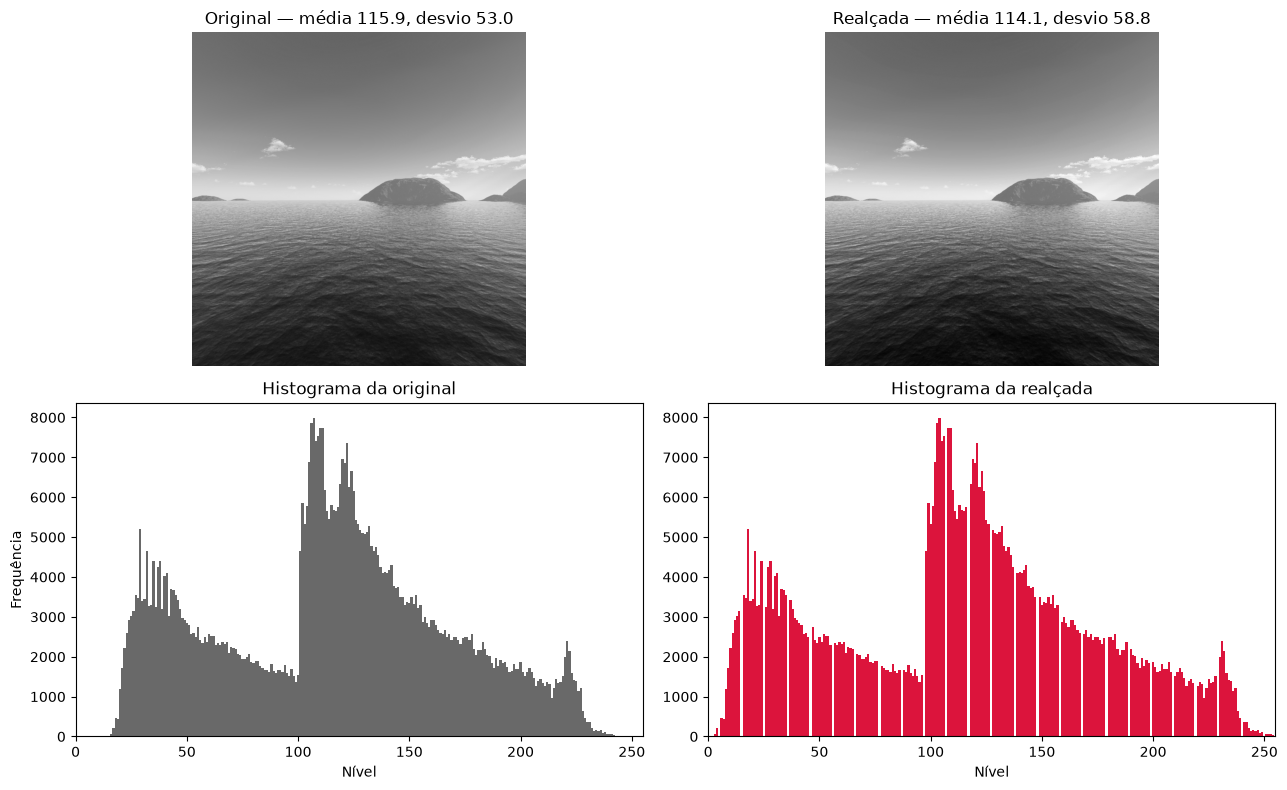

O histograma da original está comprimido numa faixa estreita; o da
realçada ocupa a escala inteira, de 0 a 255 — exatamente o objetivo
descrito no material.


In [10]:
# --- Item (a): imagens e histogramas ---

fig, eixos = plt.subplots(2, 2, figsize=(13, 8))

eixos[0, 0].imshow(cinza, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0, 0].set_title(f"Original — média {cinza.mean():.1f}, "
                      f"desvio {cinza.std():.1f}")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(cinza_realcada, cmap="gray", vmin=0, vmax=MAXVAL)
eixos[0, 1].set_title(f"Realçada — média {cinza_realcada.mean():.1f}, "
                      f"desvio {cinza_realcada.std():.1f}")
eixos[0, 1].axis("off")

teto = max(hist_antes.max(), hist_depois.max()) * 1.05

eixos[1, 0].bar(x_eixo, lido_antes, width=1.0, color="dimgray")
eixos[1, 0].set_title("Histograma da original")
eixos[1, 0].set_xlim(0, MAXVAL)
eixos[1, 0].set_ylim(0, teto)
eixos[1, 0].set_xlabel("Nível")
eixos[1, 0].set_ylabel("Frequência")

eixos[1, 1].bar(x_eixo, lido_depois, width=1.0, color="crimson")
eixos[1, 1].set_title("Histograma da realçada")
eixos[1, 1].set_xlim(0, MAXVAL)
eixos[1, 1].set_ylim(0, teto)
eixos[1, 1].set_xlabel("Nível")

plt.tight_layout()
plt.show()

print("O histograma da original está comprimido numa faixa estreita; o da")
print("realçada ocupa a escala inteira, de 0 a 255 — exatamente o objetivo")
print("descrito no material.")

Níveis com frequência zero — antes : 25
Níveis com frequência zero — depois: 25

Antes, os níveis vazios estavam nos extremos (a imagem não usava as
pontas da escala). Depois, eles aparecem distribuídos no meio, como
lacunas entre os níveis afastados pelo alongamento.


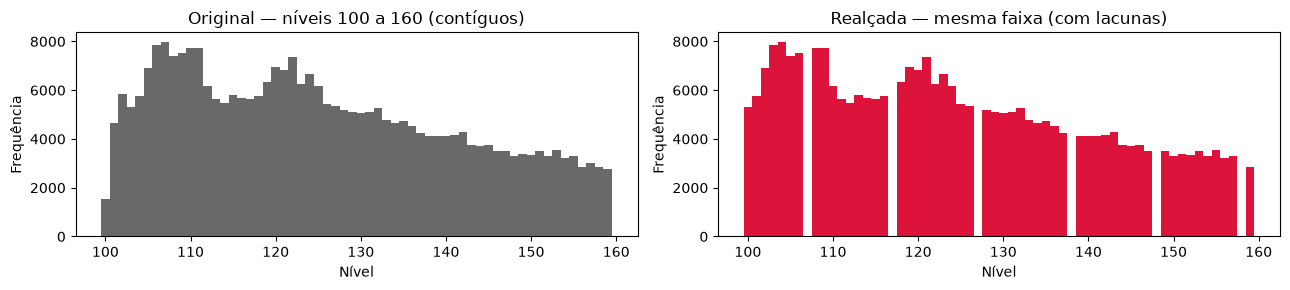


Contagem de níveis ocupados: 231 antes, 231 depois.
A igualdade confirma que a transformação é injetora sobre os níveis
presentes: nenhum detalhe novo foi criado, apenas redistribuído.


In [11]:
# --- Item (a): o efeito "pente" em detalhe ---

vazios_antes = int((hist_antes == 0).sum())
vazios_depois = int((hist_depois == 0).sum())

print(f"Níveis com frequência zero — antes : {vazios_antes}")
print(f"Níveis com frequência zero — depois: {vazios_depois}")
print()
print("Antes, os níveis vazios estavam nos extremos (a imagem não usava as")
print("pontas da escala). Depois, eles aparecem distribuídos no meio, como")
print("lacunas entre os níveis afastados pelo alongamento.")

# Zoom numa faixa estreita para tornar o padrão visível
faixa = slice(100, 160)
fig, eixos = plt.subplots(1, 2, figsize=(13, 3))

eixos[0].bar(x_eixo[faixa], hist_antes[faixa], width=1.0, color="dimgray")
eixos[0].set_title("Original — níveis 100 a 160 (contíguos)")
eixos[1].bar(x_eixo[faixa], hist_depois[faixa], width=1.0, color="crimson")
eixos[1].set_title("Realçada — mesma faixa (com lacunas)")
for ax in eixos:
    ax.set_xlabel("Nível")
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

print()
print(f"Contagem de níveis ocupados: {int((hist_antes > 0).sum())} antes, "
      f"{int((hist_depois > 0).sum())} depois.")
print("A igualdade confirma que a transformação é injetora sobre os níveis")
print("presentes: nenhum detalhe novo foi criado, apenas redistribuído.")

---

## Item (b) — Realce sobre a imagem PPM (RGB)

Aqui surge uma decisão de projeto que o material não aborda, porque trata de
imagens em tons de cinza. Há duas formas de aplicar a função de transferência a
uma imagem colorida, e elas produzem resultados visualmente distintos.

### Estratégia 1 — realce por canal

Cada canal é tratado como uma imagem independente, com seus próprios `Xmin`,
`Xmax`, `a` e `b`. Os três canais passam a ocupar a escala inteira.

Como cada canal recebe um ganho diferente, a **proporção entre as componentes de
cada píxel muda** — e proporção entre componentes é justamente o que define o
matiz. O efeito é semelhante ao de um balanço de branco automático: dominantes de
cor são atenuadas, o que pode ser desejável ou não.

### Estratégia 2 — realce global

Um único par `(a, b)`, calculado a partir do mínimo e do máximo considerando os
três canais em conjunto, é aplicado igualmente a todos.

Como as três componentes sofrem a mesma transformação afim, a razão entre elas é
preservada de forma aproximada e o matiz se mantém. Em contrapartida, o
alongamento é mais fraco: ele é limitado pelo canal de faixa mais larga.

### Qual entregar

O enunciado pede a função de transferência do material aplicada à imagem RGB,
sem especificar. Adoto o **realce por canal** como resultado principal, por ser a
leitura mais direta do procedimento ("percorre-se a imagem X para descobrir seus
valores mínimo e máximo" — aplicado a cada canal), e gravo também a versão
global para comparação.

In [12]:
# --- Item (b): leitura e parâmetros por canal ---

rgb, mv, magic = ler_pnm(ARQUIVO_PPM)
assert magic == "P3" and mv == MAXVAL
altura_c, largura_c, _ = rgb.shape

CANAIS = ("R", "G", "B")
NOMES = ("Vermelho", "Verde", "Azul")
CORES = ("red", "green", "blue")

params = [parametros_realce(rgb[:, :, c]) for c in range(3)]

print("IMAGEM ORIGINAL")
print("-" * 58)
print(f"Dimensões: {largura_c} x {altura_c}  "
      f"({largura_c * altura_c:,} píxeis)")
print()
print(f"{'Canal':<12}{'Xmin':>6}{'Xmax':>6}{'a':>10}{'b':>10}{'Faixa':>8}")
print("-" * 58)
for c, nome in enumerate(NOMES):
    a_c, b_c, xmin_c, xmax_c = params[c]
    print(f"{nome:<12}{xmin_c:>6}{xmax_c:>6}{a_c:>10.4f}{b_c:>10.2f}"
          f"{xmax_c - xmin_c + 1:>8}")

a_glob, b_glob, xmin_glob, xmax_glob = parametros_realce(rgb)
print()
print(f"{'Global':<12}{xmin_glob:>6}{xmax_glob:>6}{a_glob:>10.4f}{b_glob:>10.2f}"
      f"{xmax_glob - xmin_glob + 1:>8}")
print()
print("Note que o canal Azul já atinge o máximo da escala. Esse detalhe será")
print("retomado adiante, ao responder à pergunta deixada no material.")

IMAGEM ORIGINAL
----------------------------------------------------------
Dimensões: 800 x 800  (640,000 píxeis)

Canal         Xmin  Xmax         a         b   Faixa
----------------------------------------------------------
Vermelho         9   243    1.0897     -9.81     235
Verde           13   244    1.1039    -14.35     232
Azul            22   255    1.0944    -24.08     234

Global           9   255    1.0366     -9.33     247

Note que o canal Azul já atinge o máximo da escala. Esse detalhe será
retomado adiante, ao responder à pergunta deixada no material.


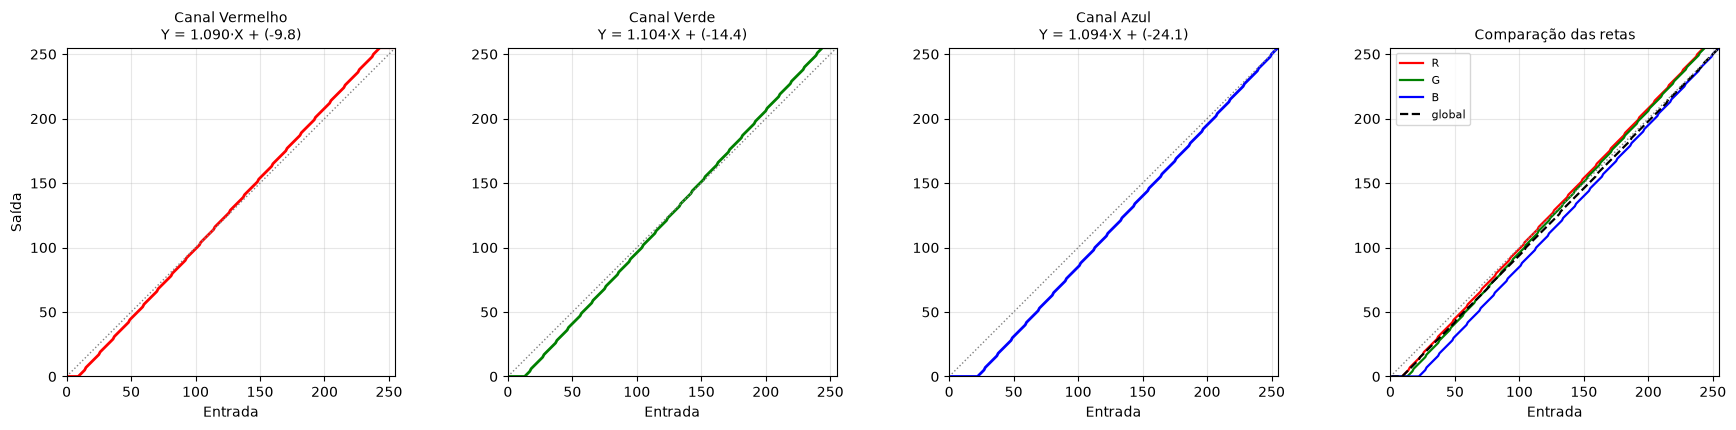

As três retas por canal têm inclinações e interceptos distintos — é
essa diferença que altera o balanço de cor. A reta global (tracejada)
é única e mais próxima da identidade.


In [13]:
# --- Item (b): gráficos das funções de transferência ---

fig, eixos = plt.subplots(1, 4, figsize=(18, 4.2))

for c, (nome, cor) in enumerate(zip(NOMES, CORES)):
    a_c, b_c, xmin_c, xmax_c = params[c]
    y = np.clip(np.rint(a_c * x_eixo + b_c), 0, MAXVAL)

    eixos[c].plot(x_eixo, y, color=cor, linewidth=2)
    eixos[c].plot(x_eixo, x_eixo, color="gray", linestyle=":", linewidth=1)
    eixos[c].set_title(f"Canal {nome}\nY = {a_c:.3f}·X + ({b_c:.1f})", fontsize=10)
    eixos[c].set_xlabel("Entrada")
    eixos[c].set_xlim(0, MAXVAL)
    eixos[c].set_ylim(0, MAXVAL)
    eixos[c].set_aspect("equal")
    eixos[c].grid(alpha=0.3)

eixos[0].set_ylabel("Saída")

# Painel comparativo: as três retas sobrepostas + a global
for c, (canal, cor) in enumerate(zip(CANAIS, CORES)):
    a_c, b_c, _, _ = params[c]
    eixos[3].plot(x_eixo, np.clip(np.rint(a_c * x_eixo + b_c), 0, MAXVAL),
                  color=cor, linewidth=1.6, label=canal)
eixos[3].plot(x_eixo, np.clip(np.rint(a_glob * x_eixo + b_glob), 0, MAXVAL),
              color="black", linestyle="--", linewidth=1.6, label="global")
eixos[3].plot(x_eixo, x_eixo, color="gray", linestyle=":", linewidth=1)
eixos[3].set_title("Comparação das retas", fontsize=10)
eixos[3].set_xlabel("Entrada")
eixos[3].set_xlim(0, MAXVAL)
eixos[3].set_ylim(0, MAXVAL)
eixos[3].set_aspect("equal")
eixos[3].grid(alpha=0.3)
eixos[3].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("As três retas por canal têm inclinações e interceptos distintos — é")
print("essa diferença que altera o balanço de cor. A reta global (tracejada)")
print("é única e mais próxima da identidade.")

In [14]:
# --- Item (b): aplicação das duas estratégias ---

# Estratégia 1: por canal
rgb_por_canal = np.zeros_like(rgb)
for c in range(3):
    a_c, b_c, _, _ = params[c]
    rgb_por_canal[:, :, c] = aplicar_realce(rgb[:, :, c], a_c, b_c)

# Estratégia 2: global
rgb_global = aplicar_realce(rgb, a_glob, b_glob)

print(f"{'Canal':<10}{'original':>22}{'por canal':>22}{'global':>22}")
print(f"{'':<10}{'mín/máx  média':>22}{'mín/máx  média':>22}{'mín/máx  média':>22}")
print("-" * 78)
for c, nome in enumerate(CANAIS):
    o, p, g = rgb[:, :, c], rgb_por_canal[:, :, c], rgb_global[:, :, c]
    print(f"{nome:<10}"
          f"{f'{o.min():3d}/{o.max():3d}  {o.mean():6.2f}':>22}"
          f"{f'{p.min():3d}/{p.max():3d}  {p.mean():6.2f}':>22}"
          f"{f'{g.min():3d}/{g.max():3d}  {g.mean():6.2f}':>22}")

print()
print(f"Desvio padrão global: original {rgb.std():.2f} | "
      f"por canal {rgb_por_canal.std():.2f} | global {rgb_global.std():.2f}")
print()
print("No realce por canal os três chegam a 0 e 255. No global, apenas o")
print("canal que continha o mínimo e o que continha o máximo atingem os")
print("extremos — os demais ficam aquém.")

Canal                   original             por canal                global
                  mín/máx  média        mín/máx  média        mín/máx  média
------------------------------------------------------------------------------
R                  9/243   97.33         0/255   96.26         0/243   91.59
G                 13/244  116.94         0/255  114.74         4/244  111.91
B                 22/255  154.57         0/255  145.09        13/255  150.89

Desvio padrão global: original 58.70 | por canal 62.20 | global 60.84

No realce por canal os três chegam a 0 e 255. No global, apenas o
canal que continha o mínimo e o que continha o máximo atingem os
extremos — os demais ficam aquém.


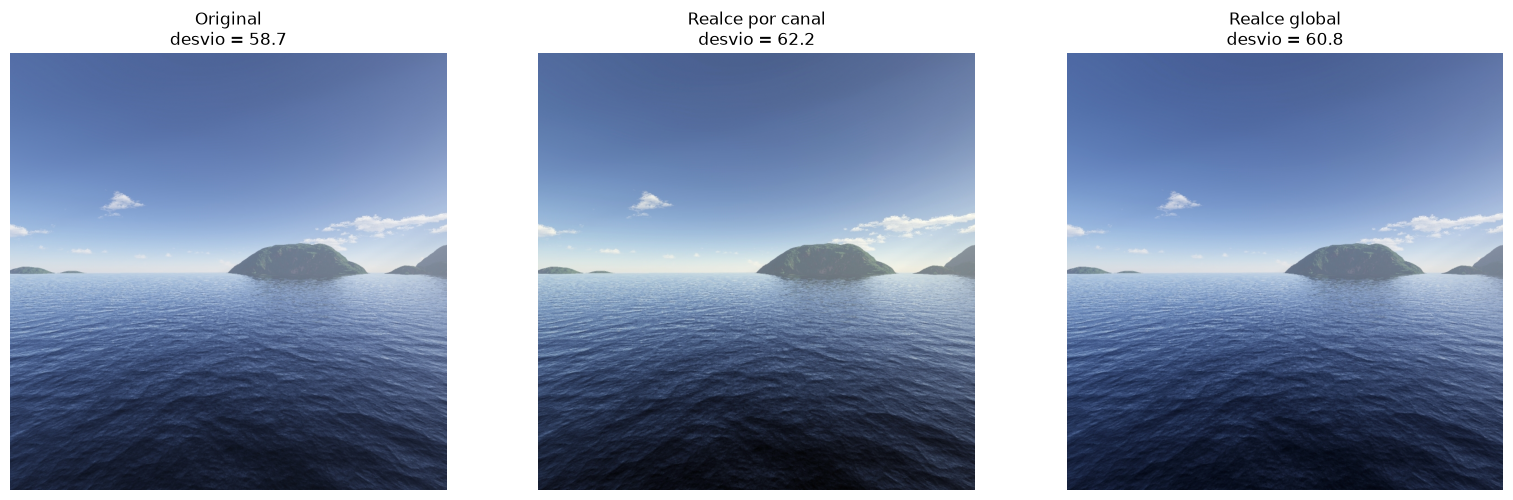

Estratégia                 R/G       B/G
----------------------------------------
Original                0.8323    1.3218
Por canal               0.8390    1.2646
Global                  0.8185    1.3484

As razões entre canais medem o balanço de cor. O realce global as
altera pouco; o realce por canal as aproxima de 1, o que caracteriza
a atenuação de dominantes — comportamento de balanço de branco.


In [15]:
# --- Item (b): comparação visual das estratégias ---

fig, eixos = plt.subplots(1, 3, figsize=(16, 5))

eixos[0].imshow(rgb / MAXVAL)
eixos[0].set_title(f"Original\ndesvio = {rgb.std():.1f}")

eixos[1].imshow(rgb_por_canal / MAXVAL)
eixos[1].set_title(f"Realce por canal\ndesvio = {rgb_por_canal.std():.1f}")

eixos[2].imshow(rgb_global / MAXVAL)
eixos[2].set_title(f"Realce global\ndesvio = {rgb_global.std():.1f}")

for ax in eixos:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Quanto o matiz mudou: razão entre as médias dos canais
print(f"{'Estratégia':<20}{'R/G':>10}{'B/G':>10}")
print("-" * 40)
for nome, img in (("Original", rgb), ("Por canal", rgb_por_canal),
                  ("Global", rgb_global)):
    r_g = img[:, :, 0].mean() / img[:, :, 1].mean()
    b_g = img[:, :, 2].mean() / img[:, :, 1].mean()
    print(f"{nome:<20}{r_g:>10.4f}{b_g:>10.4f}")

print()
print("As razões entre canais medem o balanço de cor. O realce global as")
print("altera pouco; o realce por canal as aproxima de 1, o que caracteriza")
print("a atenuação de dominantes — comportamento de balanço de branco.")

In [16]:
# --- Item (b): gravação das imagens ---

PPM_CANAL = SAIDA / "b_realcada_por_canal.ppm"
PPM_GLOBAL = SAIDA / "b_realcada_global.ppm"

escrever_ppm_p3(
    PPM_CANAL, rgb_por_canal, MAXVAL,
    comentario=(f"item (b) - realce linear por canal - "
                f"R: a={params[0][0]:.4f} b={params[0][1]:.2f} | "
                f"G: a={params[1][0]:.4f} b={params[1][1]:.2f} | "
                f"B: a={params[2][0]:.4f} b={params[2][1]:.2f} - "
                f"origem {ARQUIVO_PPM.name}")
)

escrever_ppm_p3(
    PPM_GLOBAL, rgb_global, MAXVAL,
    comentario=(f"item (b) - realce linear global - "
                f"Y = {a_glob:.6f}*X + ({b_glob:.6f}) - "
                f"Xmin={xmin_glob} Xmax={xmax_glob} - origem {ARQUIVO_PPM.name}")
)

for caminho, esperado in ((PPM_CANAL, rgb_por_canal), (PPM_GLOBAL, rgb_global)):
    lida, mv_s, magic_s = ler_pnm(caminho)
    assert magic_s == "P3" and mv_s == MAXVAL and np.array_equal(lida, esperado)
    print(f"{caminho.name:<32} round-trip OK | "
          f"col. máx {verificar_limite_colunas(caminho)} | "
          f"{caminho.stat().st_size / 1024**2:.2f} MB")

b_realcada_por_canal.ppm         round-trip OK | col. máx 66 | 6.61 MB
b_realcada_global.ppm            round-trip OK | col. máx 66 | 6.59 MB


In [17]:
# --- Item (b): histogramas e CSV ---

hists_antes = [histograma(rgb[:, :, c]) for c in range(3)]
hists_depois = [histograma(rgb_por_canal[:, :, c]) for c in range(3)]

n_px = largura_c * altura_c
for h in hists_antes + hists_depois:
    assert h.sum() == n_px

CSV_B = SAIDA / "b_histogramas_antes_depois_rgb.csv"

with open(CSV_B, "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f)
    w.writerow(["nivel",
                "orig_R", "orig_G", "orig_B",
                "realc_R", "realc_G", "realc_B"])
    for i in range(N_NIVEIS):
        w.writerow([i] + [int(h[i]) for h in hists_antes]
                       + [int(h[i]) for h in hists_depois])

with open(CSV_B, encoding="utf-8", newline="") as f:
    linhas_b = list(csv.DictReader(f))

for c, canal in enumerate(CANAIS):
    assert np.array_equal(
        np.array([int(l[f"orig_{canal}"]) for l in linhas_b]), hists_antes[c])
    assert np.array_equal(
        np.array([int(l[f"realc_{canal}"]) for l in linhas_b]), hists_depois[c])

print(f"Arquivo gravado : {CSV_B.name}  ({len(linhas_b)} linhas)")
print(f"Round-trip      : OK nos seis histogramas")
print()
with open(CSV_B, encoding="utf-8") as f:
    for _ in range(4):
        print(f.readline().rstrip())
print("...")

Arquivo gravado : b_histogramas_antes_depois_rgb.csv  (256 linhas)
Round-trip      : OK nos seis histogramas

nivel,orig_R,orig_G,orig_B,realc_R,realc_G,realc_B
0,0,0,0,1,1,1
1,0,0,0,19,8,1
2,0,0,0,69,16,0
...


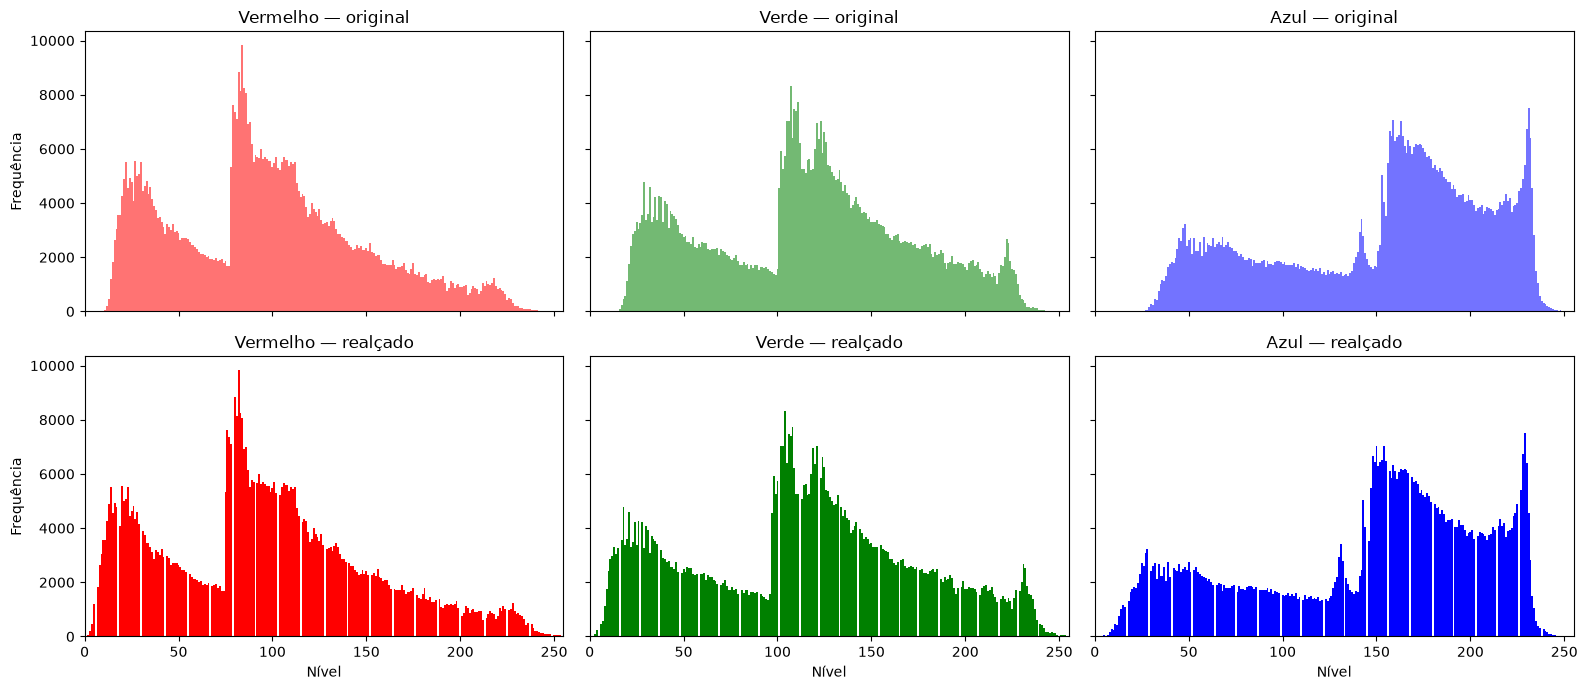

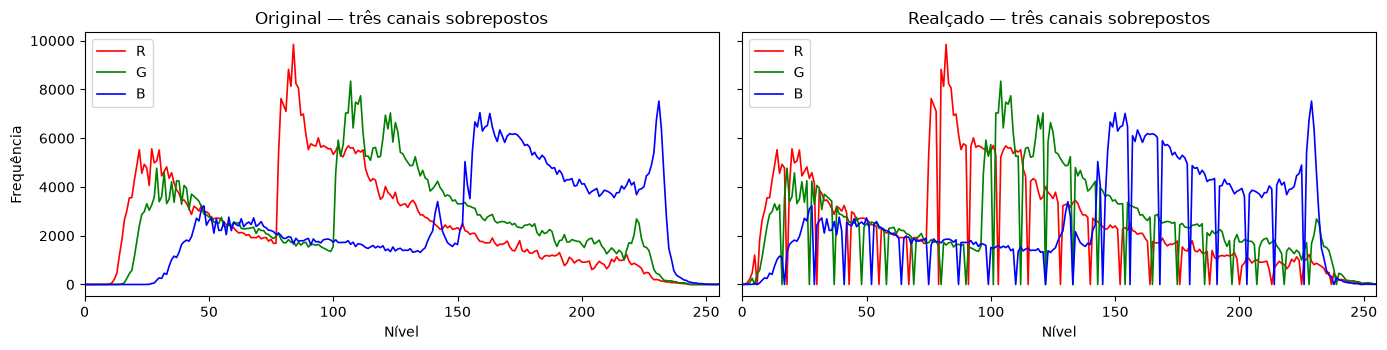

In [18]:
# --- Item (b): histogramas antes e depois, por canal ---

teto_b = max(max(h.max() for h in hists_antes),
             max(h.max() for h in hists_depois)) * 1.05

fig, eixos = plt.subplots(2, 3, figsize=(16, 7), sharex=True, sharey=True)

for c, (nome, cor) in enumerate(zip(NOMES, CORES)):
    eixos[0, c].bar(x_eixo, hists_antes[c], width=1.0, color=cor, alpha=0.55)
    eixos[0, c].set_title(f"{nome} — original")

    eixos[1, c].bar(x_eixo, hists_depois[c], width=1.0, color=cor)
    eixos[1, c].set_title(f"{nome} — realçado")

    for linha in range(2):
        eixos[linha, c].set_xlim(0, MAXVAL)
        eixos[linha, c].set_ylim(0, teto_b)

eixos[1, 0].set_xlabel("Nível")
eixos[1, 1].set_xlabel("Nível")
eixos[1, 2].set_xlabel("Nível")
eixos[0, 0].set_ylabel("Frequência")
eixos[1, 0].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# Curvas sobrepostas, antes e depois
fig, eixos = plt.subplots(1, 2, figsize=(14, 3.6), sharey=True)
for c, (canal, cor) in enumerate(zip(CANAIS, CORES)):
    eixos[0].plot(x_eixo, hists_antes[c], color=cor, linewidth=1.2, label=canal)
    eixos[1].plot(x_eixo, hists_depois[c], color=cor, linewidth=1.2, label=canal)
eixos[0].set_title("Original — três canais sobrepostos")
eixos[1].set_title("Realçado — três canais sobrepostos")
for ax in eixos:
    ax.set_xlabel("Nível")
    ax.set_xlim(0, MAXVAL)
    ax.legend()
eixos[0].set_ylabel("Frequência")
plt.tight_layout()
plt.show()

## 3. A pergunta deixada no material

O material encerra com uma questão em aberto:

> Esse método não realiza nenhum realce na imagem quando existe, pelo menos, um
> píxel com nível digital mínimo e um píxel com nível digital máximo (255 para
> codificação com 8 bits). **Você pode explicar por que não se consegue realce
> quando isso ocorre?**

### Resposta

Se a imagem já contém um píxel de valor 0 e outro de valor 255, então
`Xmin = 0` e `Xmax = 255`. Substituindo nas fórmulas:

    a = 255 / (255 − 0) = 1
    b = −1 × 0 = 0

e a transformação torna-se

    Y = 1·X + 0 = X

ou seja, a **identidade**. Nenhum píxel muda de valor.

A razão de fundo é que o método é definido para levar a faixa ocupada sobre a
escala inteira. Quando a faixa ocupada **já é** a escala inteira, não há nada a
alongar: o realce linear só tem o que fazer se houver espaço sobrando nas pontas.

Vale notar que isso independe de como os píxeis se distribuem entre os extremos.
Uma imagem pode ter 99% dos píxeis concentrados numa faixa estreitíssima e,
ainda assim, não receber realce algum — basta que exista **um único** píxel em 0
e **um único** em 255. Dois píxeis isolados, possivelmente ruído, anulam o método
para a imagem inteira.

É essa fragilidade que o material aponta ao dizer que o método automático "pode,
em alguns casos, não ser eficiente", e é o que motiva a escolha manual da faixa
de interesse, tratada na seção seguinte.

A célula abaixo demonstra os dois casos numericamente. O canal Azul da imagem
deste trabalho serve de exemplo parcial: como já atinge 255, seu realce vem
apenas do lado inferior da escala.

In [19]:
# --- Demonstração do caso sem realce ---

# Caso 1: imagem que já ocupa a escala inteira
teste = cinza.copy()
teste[0, 0] = 0
teste[0, 1] = MAXVAL

a_t, b_t, xmin_t, xmax_t = parametros_realce(teste)
resultado = aplicar_realce(teste, a_t, b_t)

print("CASO 1 — imagem com um píxel em 0 e um em 255")
print("-" * 58)
print(f"Xmin = {xmin_t}, Xmax = {xmax_t}")
print(f"a = {a_t:.6f}   b = {b_t:.6f}")
print(f"Transformação: Y = {a_t:.1f}*X + {b_t:.1f}  (identidade)")
print(f"Píxeis alterados: {int((resultado != teste).sum())} de {teste.size:,}")
print(f"Desvio padrão: {teste.std():.2f} antes, {resultado.std():.2f} depois")
print()
print("Dois píxeis — 0,0003% da imagem — anularam o realce por completo.")
print()

# Caso 2: o canal Azul, que já atinge o máximo
print("CASO 2 — canal Azul da imagem deste trabalho")
print("-" * 58)
azul = rgb[:, :, 2]
a_b, b_b, xmin_b, xmax_b = params[2]
print(f"Xmin = {xmin_b}, Xmax = {xmax_b}  (o máximo já está saturado)")
print(f"a = {a_b:.6f}   ganho de apenas {(a_b - 1) * 100:.1f}%")
print(f"O alongamento vem só do lado inferior: {xmin_b} -> 0.")
print()
print(f"Para comparação, o canal Vermelho (Xmin={params[0][2]}, "
      f"Xmax={params[0][3]}) tem a = {params[0][0]:.6f}.")

CASO 1 — imagem com um píxel em 0 e um em 255
----------------------------------------------------------
Xmin = 0, Xmax = 255
a = 1.000000   b = -0.000000
Transformação: Y = 1.0*X + -0.0  (identidade)
Píxeis alterados: 0 de 640,000
Desvio padrão: 53.01 antes, 53.01 depois

Dois píxeis — 0,0003% da imagem — anularam o realce por completo.

CASO 2 — canal Azul da imagem deste trabalho
----------------------------------------------------------
Xmin = 22, Xmax = 255  (o máximo já está saturado)
a = 1.094421   ganho de apenas 9.4%
O alongamento vem só do lado inferior: 22 -> 0.

Para comparação, o canal Vermelho (Xmin=9, Xmax=243) tem a = 1.089744.


Faixa por min/max absolutos : [13, 243]  a = 1.1087
Faixa por percentil 1.0%     : [23, 225]  a = 1.2624

Píxeis saturados em 0   : 6,336 (0.99%)
Píxeis saturados em 255 : 5,447 (0.85%)

Desvio padrão: 53.01 original | 58.77 min/max | 66.76 percentil


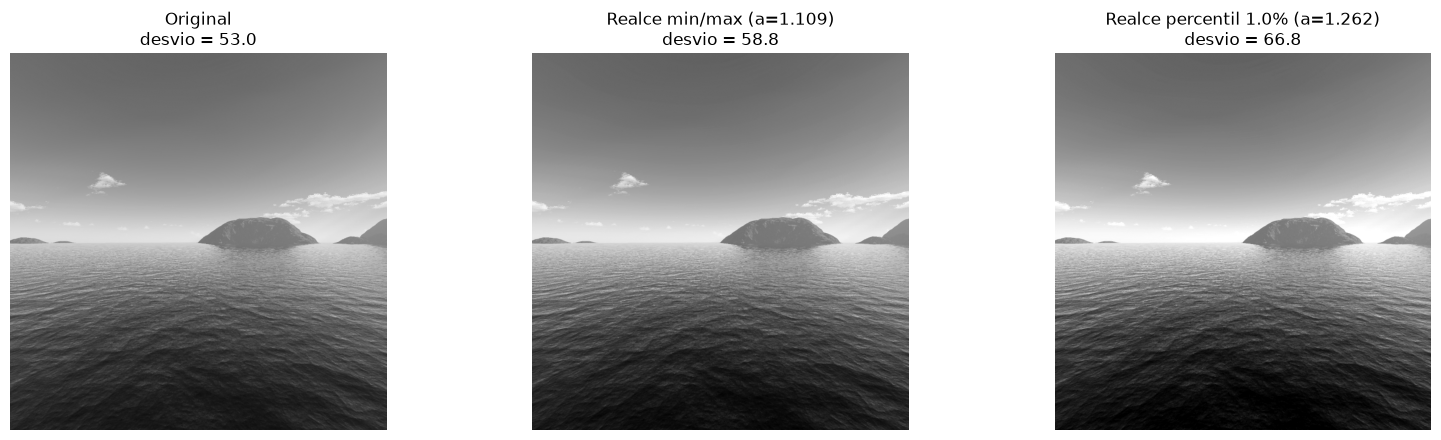


O ganho é maior porque a faixa considerada é mais estreita. O custo é
a saturação de uma pequena fração dos píxeis, que perde detalhe nas
pontas — compromisso que o material menciona ao tratar da faixa de
interesse escolhida pelo usuário.


In [20]:
# --- Bônus: faixa de interesse por percentis ---

# O material sugere aplicar a função a "faixas de maior interesse do usuário",
# mapeando para 0 e 255 o que ficar fora. Usar percentis em vez do mínimo e
# máximo absolutos torna o método imune a píxeis isolados.

PERCENTIL = 1.0
p_baixo = int(np.percentile(cinza, PERCENTIL))
p_alto = int(np.percentile(cinza, 100 - PERCENTIL))

a_p, b_p, _, _ = parametros_realce(cinza, xmin=p_baixo, xmax=p_alto)
cinza_percentil = aplicar_realce(cinza, a_p, b_p)

saturados_baixo = int((cinza < p_baixo).sum())
saturados_alto = int((cinza > p_alto).sum())

print(f"Faixa por min/max absolutos : [{xmin_g}, {xmax_g}]  a = {a_g:.4f}")
print(f"Faixa por percentil {PERCENTIL}%     : [{p_baixo}, {p_alto}]  a = {a_p:.4f}")
print()
print(f"Píxeis saturados em 0   : {saturados_baixo:,} "
      f"({saturados_baixo / cinza.size * 100:.2f}%)")
print(f"Píxeis saturados em 255 : {saturados_alto:,} "
      f"({saturados_alto / cinza.size * 100:.2f}%)")
print()
print(f"Desvio padrão: {cinza.std():.2f} original | "
      f"{cinza_realcada.std():.2f} min/max | {cinza_percentil.std():.2f} percentil")

fig, eixos = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, img, titulo in zip(
        eixos,
        (cinza, cinza_realcada, cinza_percentil),
        ("Original", f"Realce min/max (a={a_g:.3f})",
         f"Realce percentil {PERCENTIL}% (a={a_p:.3f})")):
    ax.imshow(img, cmap="gray", vmin=0, vmax=MAXVAL)
    ax.set_title(f"{titulo}\ndesvio = {img.std():.1f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

print()
print("O ganho é maior porque a faixa considerada é mais estreita. O custo é")
print("a saturação de uma pequena fração dos píxeis, que perde detalhe nas")
print("pontas — compromisso que o material menciona ao tratar da faixa de")
print("interesse escolhida pelo usuário.")

In [21]:
# --- Verificação final dos arquivos gerados ---

gerados = [
    ("(a) imagem realçada", PGM_SAIDA, "P2"),
    ("(a) histogramas CSV", CSV_A, "csv"),
    ("(b) realce por canal", PPM_CANAL, "P3"),
    ("(b) realce global", PPM_GLOBAL, "P3"),
    ("(b) histogramas CSV", CSV_B, "csv"),
]

print(f"{'Entregável':<24}{'Arquivo':<36}{'Tipo':>6}{'Tamanho':>12}")
print("-" * 80)
for rotulo, caminho, tipo in gerados:
    tam = caminho.stat().st_size
    unidade = f"{tam / 1024**2:.2f} MB" if tam > 1024**2 else f"{tam / 1024:.1f} KB"
    print(f"{rotulo:<24}{caminho.name:<36}{tipo:>6}{unidade:>12}")

print()
print("PARÂMETROS APLICADOS")
print("-" * 52)
print(f"(a) PGM        : Y = {a_g:.6f}*X + ({b_g:.6f})")
for c, nome in enumerate(NOMES):
    a_c, b_c, _, _ = params[c]
    print(f"(b) canal {nome:<6}: Y = {a_c:.6f}*X + ({b_c:.6f})")
print(f"(b) global     : Y = {a_glob:.6f}*X + ({b_glob:.6f})")

Entregável              Arquivo                               Tipo     Tamanho
--------------------------------------------------------------------------------
(a) imagem realçada     a_realcada_linear.pgm                   P2     2.23 MB
(a) histogramas CSV     a_histogramas_antes_depois.csv         csv      9.0 KB
(b) realce por canal    b_realcada_por_canal.ppm                P3     6.61 MB
(b) realce global       b_realcada_global.ppm                   P3     6.59 MB
(b) histogramas CSV     b_histogramas_antes_depois_rgb.csv     csv      8.0 KB

PARÂMETROS APLICADOS
----------------------------------------------------
(a) PGM        : Y = 1.108696*X + (1.348353)
(b) canal Vermelho: Y = 1.089744*X + (-9.807692)
(b) canal Verde : Y = 1.103896*X + (-14.350649)
(b) canal Azul  : Y = 1.094421*X + (-24.077253)
(b) global     : Y = 1.036585*X + (-9.329268)


---

## Conclusões

### Entregáveis

| Item | Arquivo | Conteúdo |
|------|---------|----------|
| (a) | `a_realcada_linear.pgm` | imagem PGM realçada |
| (a) | `a_histogramas_antes_depois.csv` | histogramas original e realçado |
| (b) | `b_realcada_por_canal.ppm` | RGB com realce independente por canal |
| (b) | `b_realcada_global.ppm` | RGB com realce global (comparação) |
| (b) | `b_histogramas_antes_depois_rgb.csv` | seis histogramas, três canais |

Todos validados por round-trip, com magic number e `maxval` conferidos e nenhuma
linha excedendo 70 caracteres. Os gráficos de histograma foram traçados a partir
dos CSV relidos do disco.

### Sobre a validação da implementação

A função foi testada contra o exemplo numérico do próprio material antes de ser
aplicada às imagens. Os parâmetros `a = 5,0` e `b = −20,0` coincidiram
exatamente, e oito das nove posições da matriz de saída também. A divergência
restante — o material apresenta 40 onde `Y = 5·10 − 20 = 30` — foi verificada
contra a fórmula do próprio material e parece ser erro de digitação do slide.

Usar o exemplo do material como teste, em vez de apenas reproduzi-lo, é o que
permitiu localizar a inconsistência.

### O que o realce faz

O desvio padrão cresce, que é a medida objetiva do ganho de contraste, e o
histograma passa a ocupar a escala inteira — exatamente o objetivo enunciado no
material.

A contagem de níveis ocupados, porém, **não muda**. A transformação é monotônica
e injetora: ela afasta os níveis existentes uns dos outros, deixando lacunas
entre eles, sem criar nenhum nível novo. O histograma da imagem realçada ganha
aspecto de pente por essa razão.

Isso delimita com precisão o que o realce entrega: melhora a **legibilidade** da
informação já presente, tornando visíveis diferenças que estavam comprimidas
numa faixa estreita demais. Não recupera detalhe perdido nem acrescenta
informação — ao contrário das operações destrutivas das atividades anteriores,
esta é reversível em princípio, já que a reta é invertível onde não há saturação.

### A decisão específica do caso RGB

Aplicar a função canal a canal produz alongamento máximo em cada um, mas altera
as razões entre as componentes — e portanto o balanço de cor da imagem, com
efeito próximo ao de um balanço de branco automático. O realce global preserva
melhor as proporções, ao custo de um alongamento mais fraco, limitado pelo canal
de faixa mais larga.

Não há escolha universalmente correta: depende de a dominante de cor ser
característica da cena a preservar ou artefato de aquisição a corrigir. As duas
versões foram geradas para que a comparação seja possível.

### A fragilidade do método automático

A resposta à pergunta do material expõe o ponto fraco da abordagem: bastam **dois
píxeis**, um em 0 e outro em 255, para que `a = 1`, `b = 0` e a transformação se
torne a identidade — anulando o realce para a imagem inteira, por mais
concentrado que esteja o restante do histograma.

Como dois píxeis isolados podem perfeitamente ser ruído de aquisição, o método
baseado em mínimo e máximo absolutos é vulnerável a um único valor espúrio. A
alternativa demonstrada na seção final, usando percentis no lugar dos extremos,
é robusta a isso: obtém ganho maior ao custo de saturar deliberadamente uma
fração pequena e controlada dos píxeis — que é, em essência, a "faixa de maior
interesse do usuário" que o material sugere.